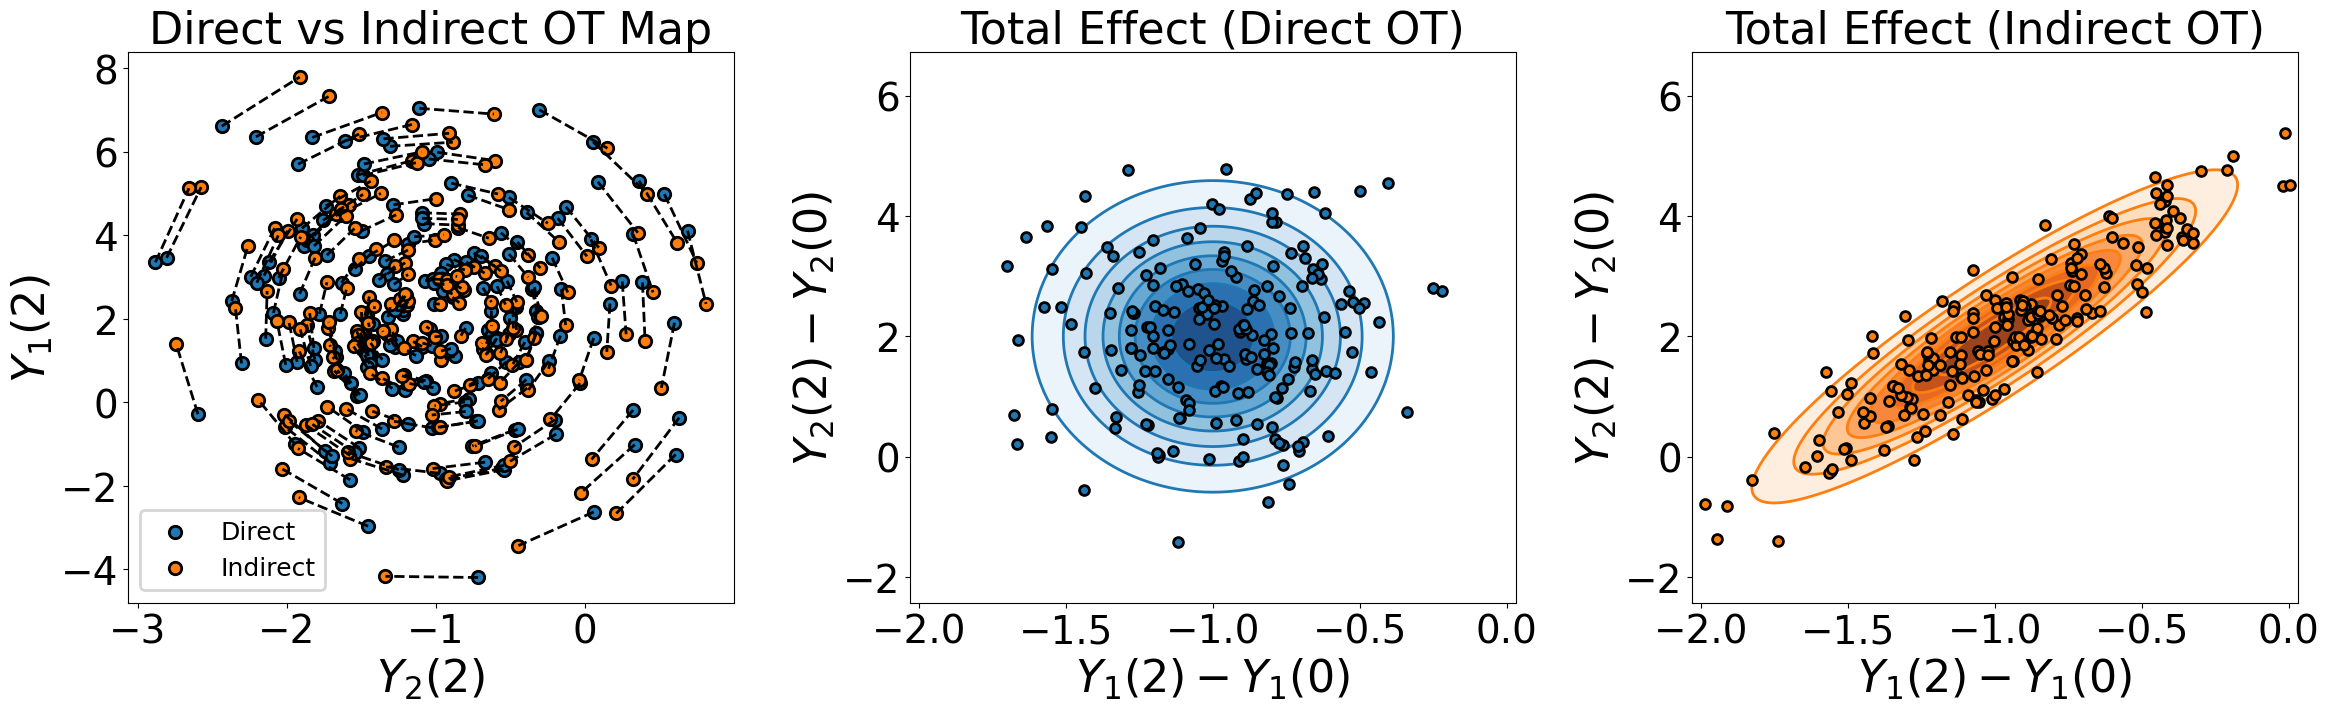

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

# Increase overall font sizes and line widths
plt.rcParams.update({
    'font.size': 36,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 18,
    'lines.linewidth': 2,
    'patch.linewidth': 2
})

# Fix random seed for reproducibility
np.random.seed(0)

# 1) Define three 2D Gaussians (means and covariances)
m0 = np.array([0.0, 0.0])
m1 = np.array([1.0, 1.0])
m2 = np.array([-1.0, 2.0])
S0 = np.array([[1.0, 0.0],
               [0.0, 1.0]])
S1 = np.array([[1.0, -0.9],
               [-0.9, 1.0]])
S2 = np.array([[0.5, 0.0],
               [0.0, 5.0]])

# Draw samples from P0
N = 200
X0 = np.random.multivariate_normal(m0, S0, size=N)

# Compute Brenier-map matrices
def compute_A(S, S_prime):
    sqrtS     = scipy.linalg.sqrtm(S)
    inv_sqrtS = scipy.linalg.inv(sqrtS)
    M         = sqrtS @ S_prime @ sqrtS
    A         = inv_sqrtS @ scipy.linalg.sqrtm(M) @ inv_sqrtS
    return A.real

A01 = compute_A(S0, S1)
A02 = compute_A(S0, S2)
A12 = compute_A(S1, S2)

# Affine Brenier transport
def T(x, A, m, m_prime):
    return (m_prime + (A @ (x - m).T).T)

# Transform and compute effects Δ = Y(2) - X0
X02_direct   = T(X0, A02, m0, m2)
X02_indirect = T(T(X0, A01, m0, m1), A12, m1, m2)
Delta_dir = X02_direct - X0
Delta_ind = X02_indirect - X0

# Prepare grid for contour shading
x_min = min(Delta_dir[:,0].min(), Delta_ind[:,0].min()) - 1
x_max = max(Delta_dir[:,0].max(), Delta_ind[:,0].max()) + 1
y_min = min(Delta_dir[:,1].min(), Delta_ind[:,1].min()) - 1
y_max = max(Delta_dir[:,1].max(), Delta_ind[:,1].max()) + 1

x = np.linspace(x_min, x_max, 300)
y = np.linspace(y_min, y_max, 300)
Xg, Yg = np.meshgrid(x, y)
pos = np.dstack([Xg, Yg])

# Multivariate normal PDF for Δ
def mvn_pdf(pos, mu, Sigma):
    det = np.linalg.det(Sigma)
    inv = np.linalg.inv(Sigma)
    norm = 1 / (2 * np.pi * np.sqrt(det))
    diff = pos - mu
    return norm * np.exp(-0.5 * np.einsum('...i,ij,...j', diff, inv, diff))

# Compute effect distribution parameters
mu = m2 - m0
Sigma_dir = (A02 - np.eye(2)) @ S0 @ (A02 - np.eye(2)).T
Sigma_ind = (A12 @ A01 - np.eye(2)) @ S0 @ (A12 @ A01 - np.eye(2)).T

# Compute densities and levels
Z_dir = mvn_pdf(pos, mu, Sigma_dir)
Z_ind = mvn_pdf(pos, mu, Sigma_ind)
levels_dir = np.linspace(Z_dir.min(), Z_dir.max(), 10)
levels_ind = np.linspace(Z_ind.min(), Z_ind.max(), 10)

# Create side-by-side subplots with larger figure size
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 1: Direct vs Indirect Brenier transport
ax = axes[0]
ax.scatter(X02_direct[:,0], X02_direct[:,1], color='C0', label='Direct', s=80, edgecolor = "black")
ax.scatter(X02_indirect[:,0], X02_indirect[:,1], color='C1', label='Indirect', s=80, edgecolor = "black")
for i in range(N):
    ax.plot([X02_direct[i,0], X02_indirect[i,0]],
            [X02_direct[i,1], X02_indirect[i,1]],
            color='black', linestyle='--', linewidth=2)
ax.set_title(r'Direct vs Indirect OT Map')
ax.set_xlabel(r"$Y_2(2)$")
ax.set_ylabel(r"$Y_1(2)$")
ax.legend()
#ax.set_aspect('equal')

# Plot 2: Direct effect
ax = axes[1]
contf1 = ax.contourf(Xg, Yg, Z_dir, levels=levels_dir[1:], extend='neither',
                     alpha=0.9, cmap='Blues')
ax.contour(Xg, Yg, Z_dir, levels=levels_dir, colors='C0', linewidths=2)
ax.scatter(Delta_dir[:,0], Delta_dir[:,1], s=50, color='C0', edgecolor='black', zorder = 100)
ax.set_title('Total Effect (Direct OT)')
ax.set_xlabel(r'$Y_1(2) - Y_1(0)$'); ax.set_ylabel(r'$Y_2(2) - Y_2(0)$')
#ax.set_aspect('equal')
ax.set_xlim(-2.03, 0.03)

# Plot 3: Indirect effect
ax = axes[2]
contf2 = ax.contourf(Xg, Yg, Z_ind, levels=levels_ind[1:], extend='neither',
                     alpha=0.9, cmap='Oranges')
ax.contour(Xg, Yg, Z_ind, levels=levels_ind, colors='C1', linewidths=2)
ax.scatter(Delta_ind[:,0], Delta_ind[:,1], s=50, color='C1', edgecolor='black', zorder = 100)
ax.set_title('Total Effect (Indirect OT)')
ax.set_xlabel(r'$Y_1(2) - Y_1(0)$'); ax.set_ylabel(r'$Y_2(2) - Y_2(0)$')
#ax.set_aspect('equal')
ax.set_xlim(-2.03, 0.03)

plt.tight_layout()
plt.savefig("brenierinconsistencylim.pdf", bbox_inches = "tight")
plt.show()

In [2]:
from scipy.stats import multivariate_normal, norm

# Two multivariate treatment-harm-rate (THR) summaries. For a continuous
# effect Delta, strict and non-strict inequalities have equal probability.
#   intersection THR = P(Delta_1 < 0 and Delta_2 < 0)
#   union THR        = P(Delta_1 < 0 or  Delta_2 < 0)
def gaussian_thrs(mean, covariance):
    marginal_negative = norm.cdf(-mean / np.sqrt(np.diag(covariance)))
    intersection = multivariate_normal.cdf(
        np.zeros(2), mean=mean, cov=covariance,
        maxpts=1_000_000, abseps=1e-10, releps=1e-10,
        rng=np.random.default_rng(0),
    )
    union = marginal_negative.sum() - intersection
    return {
        'intersection': float(intersection),
        'union': float(union),
    }

def empirical_thrs(effect_samples):
    negative = effect_samples < 0
    return {
        'intersection': float(np.mean(np.all(negative, axis=1))),
        'union': float(np.mean(np.any(negative, axis=1))),
    }

thr_results = {}
for approach, covariance, effects in (
    ('Direct OT', Sigma_dir, Delta_dir),
    ('Indirect/composed OT', Sigma_ind, Delta_ind),
):
    thr_results[approach] = {
        'population_gaussian': gaussian_thrs(mu, covariance),
        'empirical_N200': empirical_thrs(effects),
    }
    population = thr_results[approach]['population_gaussian']
    empirical = thr_results[approach]['empirical_N200']
    print(
        f"{approach}: population intersection={population['intersection']:.6f}, "
        f"population union={population['union']:.6f}; "
        f"empirical N=200 intersection={empirical['intersection']:.6f}, "
        f"empirical union={empirical['union']:.6f}"
    )


Direct OT: population intersection=0.052811, population union=0.999697; empirical N=200 intersection=0.035000, empirical union=1.000000
Indirect/composed OT: population intersection=0.065154, population union=0.994421; empirical N=200 intersection=0.060000, empirical union=0.990000


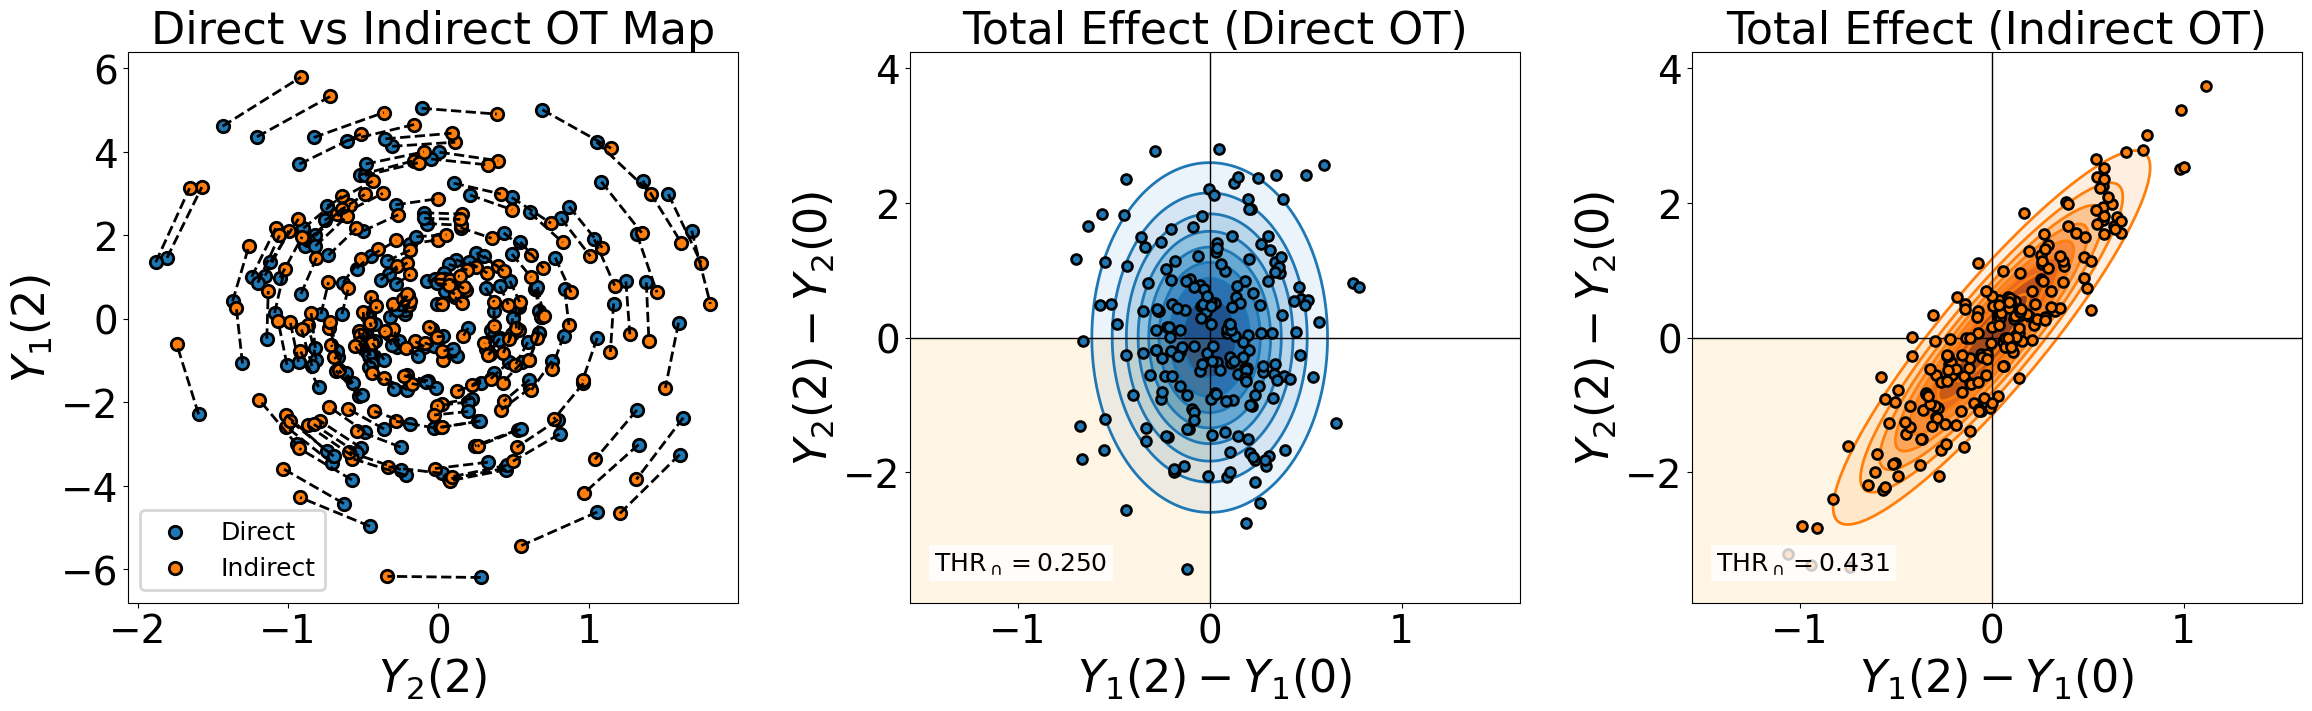

In [3]:
from matplotlib.patches import Rectangle

# Repeat the original three-panel figure after shifting Y(2), and hence
# the effect distributions, to mean (0, 0). The covariance shapes and
# the original P0 sample are unchanged.
m2_centered = np.zeros(2)
X02_direct_centered = T(X0, A02, m0, m2_centered)
X02_indirect_centered = T(
    T(X0, A01, m0, m1), A12, m1, m2_centered
)
Delta_dir_centered = X02_direct_centered - X0
Delta_ind_centered = X02_indirect_centered - X0
mu_centered = m2_centered - m0

centered_x_min = min(
    Delta_dir_centered[:, 0].min(), Delta_ind_centered[:, 0].min(), 0
) - 0.5
centered_x_max = max(
    Delta_dir_centered[:, 0].max(), Delta_ind_centered[:, 0].max(), 0
) + 0.5
centered_y_min = min(
    Delta_dir_centered[:, 1].min(), Delta_ind_centered[:, 1].min(), 0
) - 0.5
centered_y_max = max(
    Delta_dir_centered[:, 1].max(), Delta_ind_centered[:, 1].max(), 0
) + 0.5
centered_x = np.linspace(centered_x_min, centered_x_max, 300)
centered_y = np.linspace(centered_y_min, centered_y_max, 300)
Xg_centered, Yg_centered = np.meshgrid(centered_x, centered_y)
pos_centered = np.dstack([Xg_centered, Yg_centered])
Z_dir_centered = mvn_pdf(pos_centered, mu_centered, Sigma_dir)
Z_ind_centered = mvn_pdf(pos_centered, mu_centered, Sigma_ind)
levels_dir_centered = np.linspace(
    Z_dir_centered.min(), Z_dir_centered.max(), 10
)
levels_ind_centered = np.linspace(
    Z_ind_centered.min(), Z_ind_centered.max(), 10
)
centered_thrs = {
    'Direct OT': gaussian_thrs(mu_centered, Sigma_dir)['intersection'],
    'Indirect/composed OT': gaussian_thrs(
        mu_centered, Sigma_ind
    )['intersection'],
}

def plot_centered_effect(ax, density, levels, effects, color, cmap, title, thr):
    ax.contourf(
        Xg_centered, Yg_centered, density, levels=levels[1:],
        extend='neither', alpha=0.9, cmap=cmap, zorder=1,
    )
    # Light THR region: Delta_1 < 0 and Delta_2 < 0.
    ax.add_patch(Rectangle(
        (centered_x_min, centered_y_min),
        -centered_x_min, -centered_y_min,
        facecolor='orange', edgecolor='none', alpha=0.10, zorder=2,
    ))
    ax.contour(
        Xg_centered, Yg_centered, density, levels=levels,
        colors=color, linewidths=2, zorder=3,
    )
    ax.scatter(
        effects[:, 0], effects[:, 1], s=50, color=color,
        edgecolor='black', zorder=4,
    )
    ax.axhline(0, color='black', linewidth=1, zorder=3)
    ax.axvline(0, color='black', linewidth=1, zorder=3)
    ax.set_title(title)
    ax.set_xlabel(r'$Y_1(2) - Y_1(0)$')
    ax.set_ylabel(r'$Y_2(2) - Y_2(0)$')
    ax.set_xlim(centered_x_min, centered_x_max)
    ax.set_ylim(centered_y_min, centered_y_max)
    ax.text(
        0.04, 0.06, rf'$\mathrm{{THR}}_\cap={thr:.3f}$',
        transform=ax.transAxes, fontsize=18, zorder=5,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.80),
    )

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
ax = axes[0]
ax.scatter(
    X02_direct_centered[:, 0], X02_direct_centered[:, 1],
    color='C0', label='Direct', s=80, edgecolor='black',
)
ax.scatter(
    X02_indirect_centered[:, 0], X02_indirect_centered[:, 1],
    color='C1', label='Indirect', s=80, edgecolor='black',
)
for i in range(N):
    ax.plot(
        [X02_direct_centered[i, 0], X02_indirect_centered[i, 0]],
        [X02_direct_centered[i, 1], X02_indirect_centered[i, 1]],
        color='black', linestyle='--', linewidth=2,
    )
ax.set_title(r'Direct vs Indirect OT Map')
ax.set_xlabel(r'$Y_2(2)$')
ax.set_ylabel(r'$Y_1(2)$')
ax.legend()

plot_centered_effect(
    axes[1], Z_dir_centered, levels_dir_centered, Delta_dir_centered,
    'C0', 'Blues', 'Total Effect (Direct OT)', centered_thrs['Direct OT'],
)
plot_centered_effect(
    axes[2], Z_ind_centered, levels_ind_centered, Delta_ind_centered,
    'C1', 'Oranges', 'Total Effect (Indirect OT)',
    centered_thrs['Indirect/composed OT'],
)
plt.tight_layout()
plt.savefig('brenierinconsistency_centered_thr.pdf', bbox_inches='tight')
plt.savefig(
    'brenierinconsistency_centered_thr.png', dpi=200, bbox_inches='tight'
)
plt.show()
